In [62]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [63]:
n = 6
p = 0.5
G = nx.erdos_renyi_graph(n, p)
A = nx.to_numpy_array(G)
#first half of the nodes
group_1 = list(range(n // 2))
group_2 = list(range(n // 2, n))

#diagonal matrix of values between 1 and 3
D = np.diag(np.random.uniform(2, 3, n))
#diagonal matrix of values between 0 and 1
B = np.diag(np.random.uniform(0, 1, n))
#times that we switch our hybrid model 
T = [1, 10, 45, 100, 300]
#initial state
x0 = np.random.uniform(0, .3, n)
print(D)
print(B)
print(T)
# print(group_1)
# print(group_2)
# print(A)


[[2.8278793  0.         0.         0.         0.         0.        ]
 [0.         2.01417915 0.         0.         0.         0.        ]
 [0.         0.         2.5224003  0.         0.         0.        ]
 [0.         0.         0.         2.02901641 0.         0.        ]
 [0.         0.         0.         0.         2.06397447 0.        ]
 [0.         0.         0.         0.         0.         2.57738584]]
[[0.99964867 0.         0.         0.         0.         0.        ]
 [0.         0.64793356 0.         0.         0.         0.        ]
 [0.         0.         0.36574617 0.         0.         0.        ]
 [0.         0.         0.         0.66717075 0.         0.        ]
 [0.         0.         0.         0.         0.59738227 0.        ]
 [0.         0.         0.         0.         0.         0.24730488]]
[1, 10, 45, 100, 300]


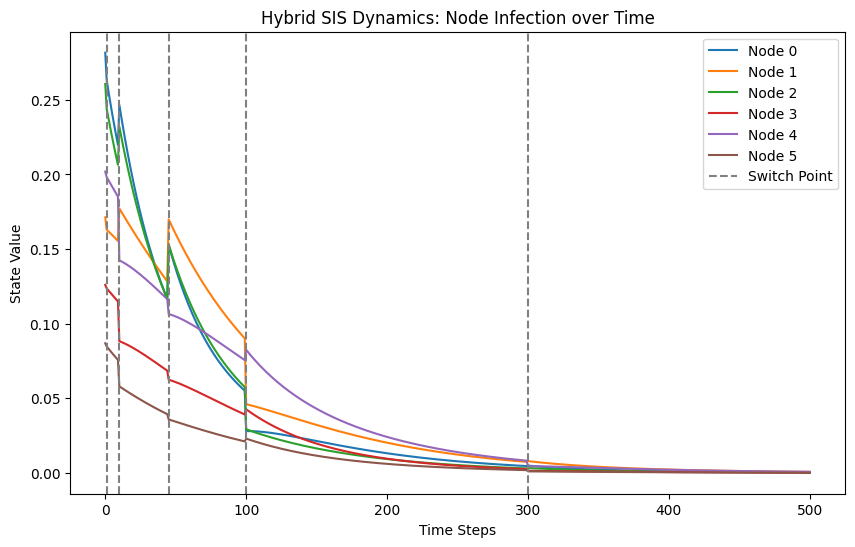

In [64]:
def group_1_switch(x_k, a_r):
    x_k[group_1] = a_r * x_k[group_1]
    return x_k

def group_2_switch(x_k, a_r):
    x_k[group_2] = a_r * x_k[group_2]
    return x_k

def simulate_dynamics(h, x, A, D, B, group_1, group_2, T, total_time):
    n = A.shape[0]
    x_k = x.copy()
    #store the state information
    states = []
    states.append(x_k)
    for k in range(total_time):
        if k in T:
            a_r_1 = np.random.uniform(0.5, 1.5)
            a_r_2 = np.random.uniform(0.5, 1.5)
            # print("scaling factors: ", a_r_1, a_r_2)
            # print("before switch: ", x_k)
            x_k = group_1_switch(x_k, a_r_1)
            x_k = group_2_switch(x_k, a_r_2)
            # print("after switch: ", x_k)

        x_k_1 = h *( -D @ x_k + (np.eye(n) - np.diag(x_k))@B@A@x_k) + x_k
        x_k = x_k_1
        states.append(x_k)
    return states

total_time = 500
h = 0.01
states = simulate_dynamics(h, x0, A, D, B, group_1, group_2, T, total_time)
#plot the states over time
states = np.array(states)
plt.figure(figsize=(10, 6))
for i in range(n):
    plt.plot(states[:, i], label=f'Node {i}')
#also plot vertical lines when we switch the hybrid model
for t in T:
    plt.axvline(x=t, color='gray', linestyle='--', label='Switch Point' if t == T[0] else "")   
plt.xlabel('Time Steps')
plt.ylabel('State Value')
plt.title('Hybrid SIS Dynamics: Node Infection over Time')
plt.legend()
plt.show()